In [171]:
# Import all required libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

In [172]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [173]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks')

## DATA LOADING - Load all worker data once

In [174]:
df_w1 = pd.read_csv('w1.csv')
df_w2 = pd.read_csv('w2.csv')
df_w3 = pd.read_csv('w3.csv')
df_w4 = pd.read_csv('w4.csv')

print(f"W1 shape: {df_w1.shape}")
print(f"W2 shape: {df_w2.shape}")
print(f"W3 shape: {df_w3.shape}")
print(f"W4 shape: {df_w4.shape}")

# Concatenate all data for initial exploration
df_all = pd.concat([df_w1, df_w2, df_w3, df_w4], ignore_index=True)

W1 shape: (3029, 157)
W2 shape: (3200, 157)
W3 shape: (2700, 157)
W4 shape: (2700, 157)


In [175]:
# Define feature columns and target column
target_col = 'class'
feature_cols = [col for col in df_all.columns if col != target_col]
print(f"\nFeatures: {len(feature_cols)} columns")
print(f"Target: {target_col}")


Features: 156 columns
Target: class


## STUDIO ACTIVITY 2: Classification Report

In [176]:
# Separate features and target from all data
X_all = df_all[feature_cols].values
y_all = df_all[target_col].values

In [177]:
# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42, stratify=y_all
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Train set: (8140, 156)
Test set: (3489, 156)


In [178]:
# Define models
models = {
    'SVM': SVC(kernel='rbf', random_state=42),
    'SGD': SGDClassifier(random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
}

results = {}

In [179]:
# Train and evaluate each model
print("\nTraining and evaluating models...")
for name, model in models.items():
    print(f"\n{name} Model:")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'report': report,
        'accuracy': report['accuracy'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall']
    }


Training and evaluating models...

SVM Model:
              precision    recall  f1-score   support

           0       0.83      0.52      0.64       478
           1       0.00      0.00      0.00       103
           2       0.90      0.98      0.94      2908

    accuracy                           0.89      3489
   macro avg       0.58      0.50      0.53      3489
weighted avg       0.86      0.89      0.87      3489


SGD Model:
              precision    recall  f1-score   support

           0       0.63      0.56      0.60       478
           1       0.33      0.16      0.21       103
           2       0.91      0.95      0.93      2908

    accuracy                           0.87      3489
   macro avg       0.62      0.55      0.58      3489
weighted avg       0.86      0.87      0.86      3489


RandomForest Model:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       478
           1       0.79      0.32      0.46      

In [180]:
best_f1_model = max(results, key=lambda x: results[x]['weighted_f1'])
print(f"1) Best F1 Score (weighted avg): {best_f1_model}")
print(f"   F1 Score: {results[best_f1_model]['weighted_f1']:.4f}")

best_precision_model = max(results, key=lambda x: results[x]['weighted_precision'])
print(f"\n2) Best Precision: {best_precision_model}")
print(f"   Precision: {results[best_precision_model]['weighted_precision']:.4f}")

best_recall_model = max(results, key=lambda x: results[x]['weighted_recall'])
print(f"\n3) Best Recall: {best_recall_model}")
print(f"   Recall: {results[best_recall_model]['weighted_recall']:.4f}")

best_acc_model = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n4) Best Accuracy: {best_acc_model}")
print(f"   Accuracy: {results[best_acc_model]['accuracy']:.4f}")

print(f"\n5) Poor Performing Class Analysis:")
for name in models.keys():
    report = results[name]['report']
    print(f"\n   {name}:")
    for class_label in sorted([str(c) for c in np.unique(y_all)]):
        if class_label in report:
            f1 = report[class_label]['f1-score']
            status = "POOR" if f1 < 0.7 else "GOOD"
            print(f"      Class {class_label}: F1={f1:.3f} {status}")

1) Best F1 Score (weighted avg): RandomForest
   F1 Score: 0.9182

2) Best Precision: RandomForest
   Precision: 0.9227

3) Best Recall: RandomForest
   Recall: 0.9258

4) Best Accuracy: RandomForest
   Accuracy: 0.9258

5) Poor Performing Class Analysis:

   SVM:
      Class 0: F1=0.637 POOR
      Class 1: F1=0.000 POOR
      Class 2: F1=0.938 GOOD

   SGD:
      Class 0: F1=0.596 POOR
      Class 1: F1=0.211 POOR
      Class 2: F1=0.929 GOOD

   RandomForest:
      Class 0: F1=0.778 GOOD
      Class 1: F1=0.455 POOR
      Class 2: F1=0.958 GOOD

   MLP:
      Class 0: F1=0.563 POOR
      Class 1: F1=0.338 POOR
      Class 2: F1=0.898 GOOD


In [181]:
# Summary table
summary_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Score': [results[m]['weighted_f1'] for m in results.keys()],
    'Precision': [results[m]['weighted_precision'] for m in results.keys()],
    'Recall': [results[m]['weighted_recall'] for m in results.keys()]
}).sort_values('Accuracy', ascending=False)

print("\n\nSUMMARY TABLE:")
print(summary_df.to_string(index=False))



SUMMARY TABLE:
       Model  Accuracy  F1-Score  Precision   Recall
RandomForest  0.925767  0.918205   0.922677 0.925767
         SVM  0.890513  0.868883   0.860724 0.890513
         SGD  0.870163  0.862034   0.856802 0.870163
         MLP  0.824592  0.835616   0.853716 0.824592


## STUDIO ACTIVITY 3: Confusion Matrix


SVM Confusion Matrix:
[[ 247    0  231]
 [   2    0  101]
 [  48    0 2860]]
False Positives for SVM:
  231 cases: True=0, Predicted=2
  2 cases: True=1, Predicted=0
  101 cases: True=1, Predicted=2
  48 cases: True=2, Predicted=0

SGD Confusion Matrix:
[[ 269   29  180]
 [   2   16   85]
 [ 153    4 2751]]
False Positives for SGD:
  29 cases: True=0, Predicted=1
  180 cases: True=0, Predicted=2
  2 cases: True=1, Predicted=0
  85 cases: True=1, Predicted=2
  153 cases: True=2, Predicted=0
  4 cases: True=2, Predicted=1

RandomForest Confusion Matrix:
[[ 324    2  152]
 [   3   33   67]
 [  28    7 2873]]
False Positives for RandomForest:
  2 cases: True=0, Predicted=1
  152 cases: True=0, Predicted=2
  3 cases: True=1, Predicted=0
  67 cases: True=1, Predicted=2
  28 cases: True=2, Predicted=0
  7 cases: True=2, Predicted=1

MLP Confusion Matrix:
[[ 325   25  128]
 [  16   38   49]
 [ 335   59 2514]]
False Positives for MLP:
  25 cases: True=0, Predicted=1
  128 cases: True=0, Predic

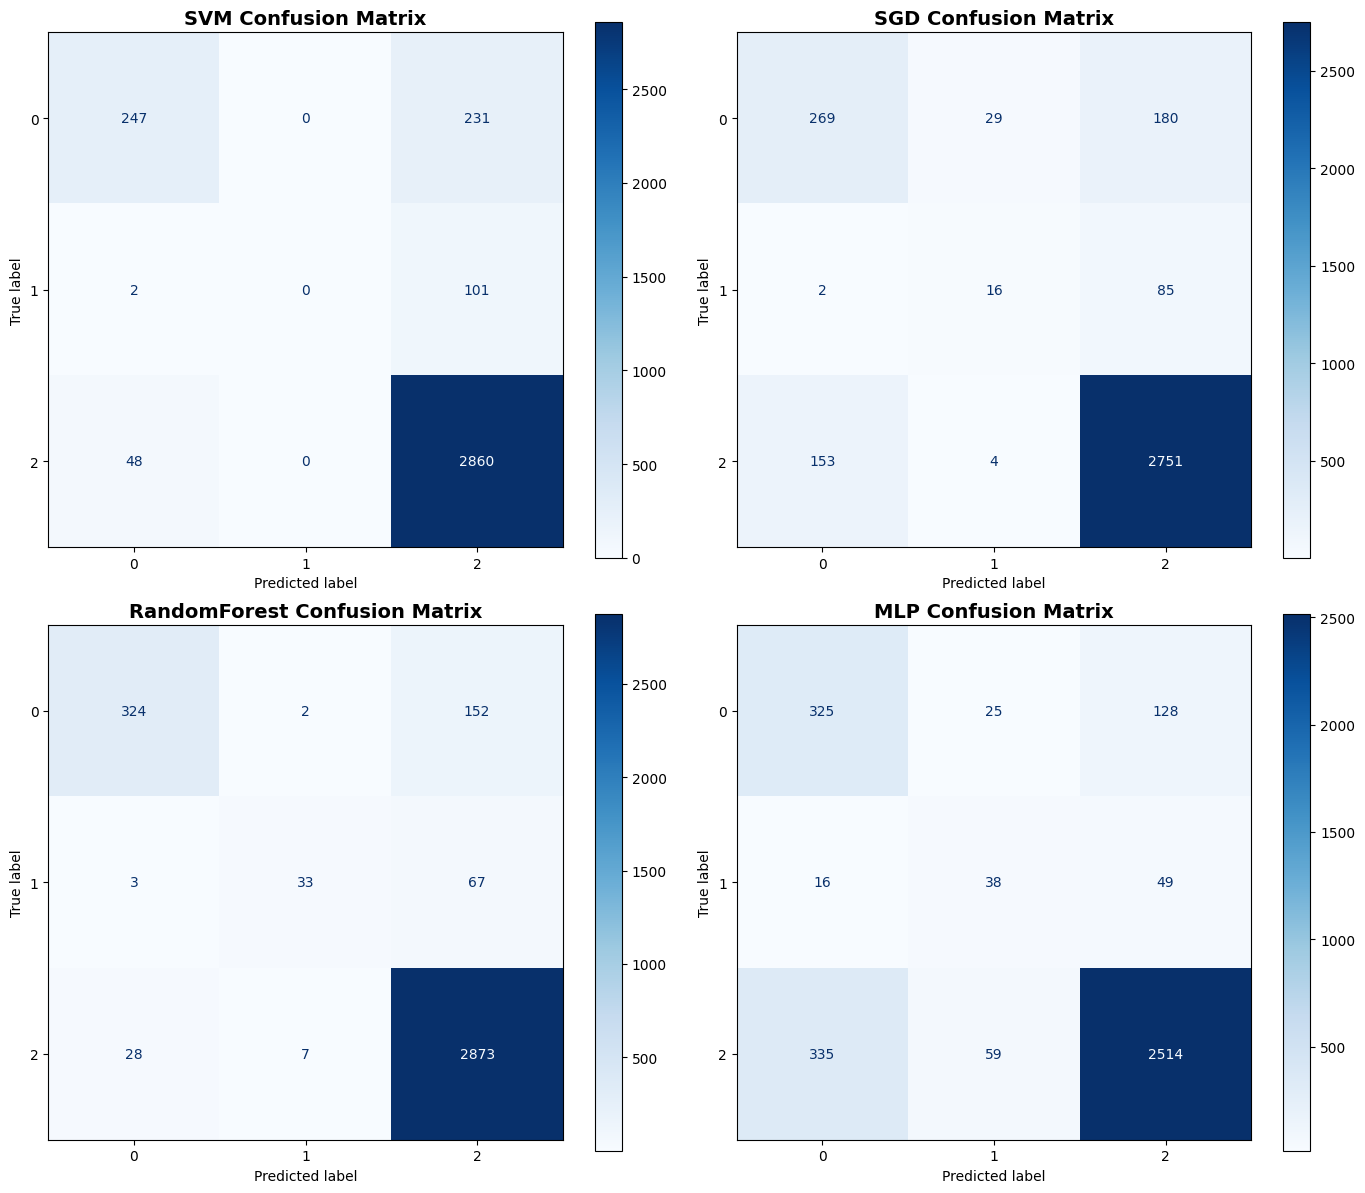

In [182]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=True)
    axes[idx].set_title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    axes[idx].grid(False)

    print(f"\n{name} Confusion Matrix:")
    print(cm)

    # Analyze false positives
    print(f"False Positives for {name}:")
    n_classes = cm.shape[0]
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j and cm[i, j] > 0:
                print(f"  {cm[i, j]} cases: True={i}, Predicted={j}")

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## STUDIO ACTIVITY 4: Class Balancing

In [183]:
# Check original class distribution
print("Original class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_train)*100:.1f}%)")

Original class distribution:
  Class 0: 1115 samples (13.7%)
  Class 1: 240 samples (2.9%)
  Class 2: 6785 samples (83.4%)



--- Approach 1: SMOTE + Tomek Links ---

After SMOTE:
  Class 0: 6785 samples (33.3%)
  Class 1: 6785 samples (33.3%)
  Class 2: 6785 samples (33.3%)

After Tomek Links:
  Class 0: 6785 samples (33.4%)
  Class 1: 6785 samples (33.4%)
  Class 2: 6774 samples (33.3%)

Classification Report (RandomForest with SMOTE + Tomek):
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       478
           1       0.59      0.43      0.50       103
           2       0.95      0.96      0.95      2908

    accuracy                           0.92      3489
   macro avg       0.78      0.72      0.74      3489
weighted avg       0.91      0.92      0.92      3489



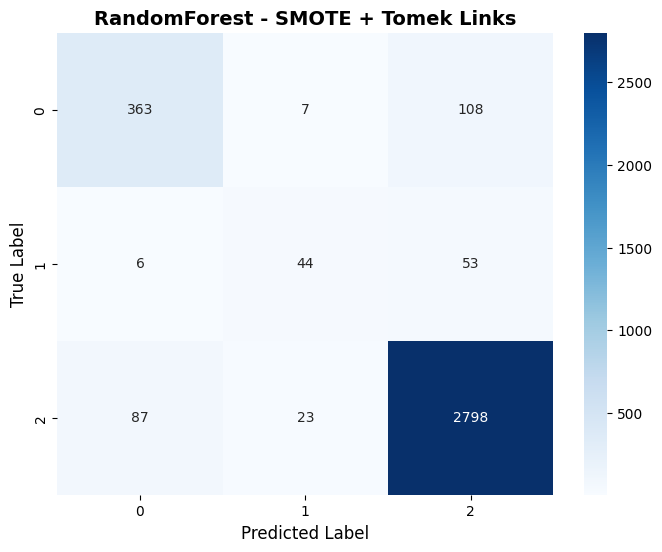

In [184]:
# Approach 1: SMOTE + Tomek Links
print("\n--- Approach 1: SMOTE + Tomek Links ---")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_train_smote)*100:.1f}%)")

tomek = TomekLinks()
X_train_balanced, y_train_balanced = tomek.fit_resample(X_train_smote, y_train_smote)

print("\nAfter Tomek Links:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_train_balanced)*100:.1f}%)")

# Train best model with balanced data
if best_acc_model == 'SVM':
    model_balanced = SVC(kernel='rbf', random_state=42)
elif best_acc_model == 'RandomForest':
    model_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
elif best_acc_model == 'SGD':
    model_balanced = SGDClassifier(random_state=42, max_iter=1000)
else:
    model_balanced = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

model_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_balanced = model_balanced.predict(X_test)

print(f"\nClassification Report ({best_acc_model} with SMOTE + Tomek):")
print(classification_report(y_test, y_pred_balanced))

acc_balanced = accuracy_score(y_test, y_pred_balanced)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{best_acc_model} - SMOTE + Tomek Links', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('confusion_matrix_balanced.png', dpi=300, bbox_inches='tight')
plt.show()

In [185]:
# Approach 2: Class Weights (dynamically calculated)
print("\n--- Approach 2: Class Weights ---")

# Use specified weights from requirements
class_weights = {0: 0.3, 1: 0.5, 2: 0.2}

print(f"Using specified class weights: {class_weights}")

if best_acc_model == 'SVM':
    model_weighted = SVC(kernel='rbf', class_weight=class_weights, random_state=42)
elif best_acc_model == 'RandomForest':
    model_weighted = RandomForestClassifier(n_estimators=100, class_weight=class_weights, random_state=42)
elif best_acc_model == 'SGD':
    model_weighted = SGDClassifier(class_weight=class_weights, random_state=42, max_iter=1000)
else:
    print("Note: MLPClassifier doesn't support class_weight parameter")
    print("Using balanced data approach instead")
    model_weighted = model_balanced

if best_acc_model != 'MLP':
    model_weighted.fit(X_train, y_train)
    y_pred_weighted = model_weighted.predict(X_test)
else:
    y_pred_weighted = y_pred_balanced

print(f"\nClassification Report ({best_acc_model} with Class Weights):")
print(classification_report(y_test, y_pred_weighted))

acc_weighted = accuracy_score(y_test, y_pred_weighted)


--- Approach 2: Class Weights ---
Using specified class weights: {0: 0.3, 1: 0.5, 2: 0.2}

Classification Report (RandomForest with Class Weights):
              precision    recall  f1-score   support

           0       0.91      0.67      0.77       478
           1       0.82      0.32      0.46       103
           2       0.93      0.99      0.96      2908

    accuracy                           0.92      3489
   macro avg       0.89      0.66      0.73      3489
weighted avg       0.92      0.92      0.92      3489



In [186]:
# Compare approaches
print("\n" + "-" * 80)
print("COMPARISON OF APPROACHES:")
print("-" * 80)
comparison_df = pd.DataFrame({
    'Approach': ['Original', 'SMOTE + Tomek', 'Class Weights'],
    'Accuracy': [results[best_acc_model]['accuracy'], acc_balanced, acc_weighted]
})
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Approach']
print(f"\nBest Approach: {best_approach}")


--------------------------------------------------------------------------------
COMPARISON OF APPROACHES:
--------------------------------------------------------------------------------
     Approach  Accuracy
     Original  0.925767
SMOTE + Tomek  0.918601
Class Weights  0.924620

Best Approach: Original


## STUDIO ACTIVITY 5: Saving ML Models

In [187]:
# Merge w1, w2, w3 data (excluding w4)
df_merged = pd.concat([df_w1, df_w2, df_w3], ignore_index=True)
print(f"Merged data (W1+W2+W3) shape: {df_merged.shape}")

X_merged = df_merged[feature_cols].values
y_merged = df_merged[target_col].values

Merged data (W1+W2+W3) shape: (8929, 157)


In [188]:
# Apply SMOTE and Tomek Links
print("\nApplying SMOTE and Tomek Links...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_merged, y_merged)

tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X_resampled, y_resampled)

print("Balanced class distribution:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples")


Applying SMOTE and Tomek Links...
Balanced class distribution:
  Class 0: 7505 samples
  Class 1: 7505 samples
  Class 2: 7497 samples


In [189]:
# Train-test split (70/30)
X_train_w123, X_test_w123, y_train_w123, y_test_w123 = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42
)

print(f"\nTrain set: {X_train_w123.shape}")
print(f"Test set: {X_test_w123.shape}")


Train set: (15754, 156)
Test set: (6753, 156)



--- Training SVM Model ---

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      2195
           1       0.85      0.98      0.91      2257
           2       0.86      0.76      0.80      2301

    accuracy                           0.86      6753
   macro avg       0.86      0.86      0.85      6753
weighted avg       0.86      0.86      0.85      6753



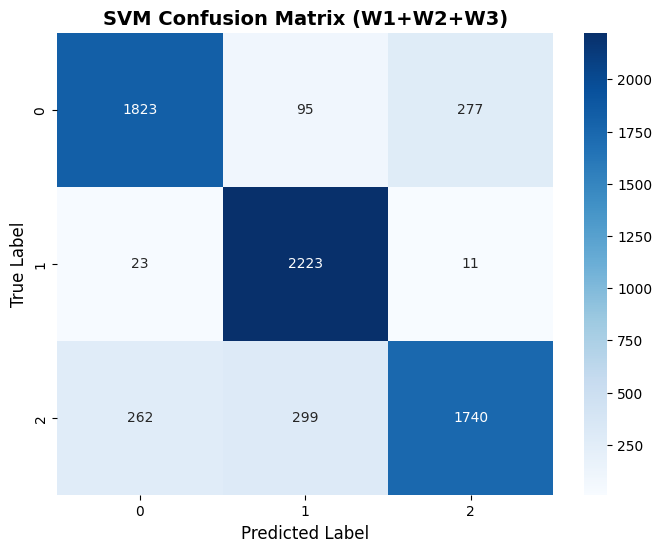


SVM model saved as: mymodel1.pkl


In [190]:
# Model 1: SVM
print("\n--- Training SVM Model ---")
clf_svm = SVC(kernel='rbf', random_state=42)
clf_svm.fit(X_train_w123, y_train_w123)
y_pred_svm = clf_svm.predict(X_test_w123)

print("\nSVM Classification Report:")
print(classification_report(y_test_w123, y_pred_svm))

cm_svm = confusion_matrix(y_test_w123, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix (W1+W2+W3)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('svm_confusion_matrix_w123.png', dpi=300, bbox_inches='tight')
plt.show()

# After saving mymodel1.pkl
filename1 = 'mymodel1.pkl'
with open(filename1, 'wb') as f:
    pickle.dump(clf_svm, f)
print(f"\nSVM model saved as: {filename1}")


--- Training Random Forest Model ---

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      2195
           1       0.98      1.00      0.99      2257
           2       0.96      0.95      0.95      2301

    accuracy                           0.97      6753
   macro avg       0.97      0.97      0.97      6753
weighted avg       0.97      0.97      0.97      6753



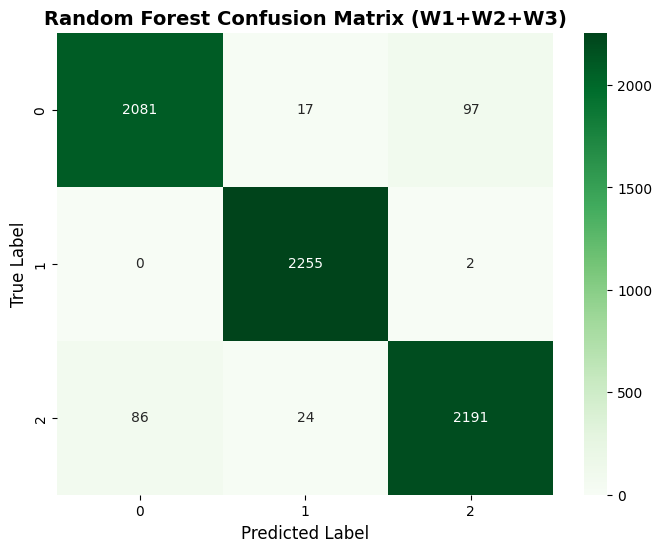


Random Forest model saved as: mymodel2.pkl


In [191]:
# Model 2: Random Forest
print("\n--- Training Random Forest Model ---")
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_w123, y_train_w123)
y_pred_rf = clf_rf.predict(X_test_w123)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_w123, y_pred_rf))

cm_rf = confusion_matrix(y_test_w123, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix (W1+W2+W3)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('rf_confusion_matrix_w123.png', dpi=300, bbox_inches='tight')
plt.show()

filename2 = 'mymodel2.pkl'
with open(filename2, 'wb') as f:
    pickle.dump(clf_rf, f)
print(f"\nRandom Forest model saved as: {filename2}")

## STUDIO ACTIVITY 6: AI from ML (Real-time Deployment)

In [192]:
# Prepare W4 data (unseen worker)
X_w4 = df_w4[feature_cols].values
y_w4 = df_w4[target_col].values

print(f"W4 data shape: {X_w4.shape}")
print(f"Total samples: {len(X_w4)}")

W4 data shape: (2700, 156)
Total samples: 2700


In [193]:
# Model 1: SVM
print("\n--- Testing Model 1 (SVM) ---")
with open(filename1, 'rb') as f:
    model1 = pickle.load(f)

counter1 = 0
predictions1 = []

for i in range(len(X_w4)):
    x_i = X_w4[i].reshape(1, -1)
    y_i = y_w4[i]
    y_pred_i = model1.predict(x_i)[0]
    predictions1.append(y_pred_i)

    if y_pred_i == y_i:
        counter1 += 1

accuracy1 = counter1 / len(y_w4)
print(f"\nModel 1 (SVM) Results:")
print(f"  Accuracy: {accuracy1:.4f} ({accuracy1*100:.2f}%)")
print(f"  Correct: {counter1}/{len(y_w4)}")
print(f"  Incorrect: {len(y_w4) - counter1}/{len(y_w4)}")



--- Testing Model 1 (SVM) ---

Model 1 (SVM) Results:
  Accuracy: 0.6711 (67.11%)
  Correct: 1812/2700
  Incorrect: 888/2700


In [194]:
# Model 2: Random Forest
print("\n--- Testing Model 2 (Random Forest) ---")
with open(filename2, 'rb') as f:
    model2 = pickle.load(f)

counter2 = 0
predictions2 = []

for i in range(len(X_w4)):
    x_i = X_w4[i].reshape(1, -1)
    y_i = y_w4[i]
    y_pred_i = model2.predict(x_i)[0]
    predictions2.append(y_pred_i)

    if y_pred_i == y_i:
        counter2 += 1

accuracy2 = counter2 / len(y_w4)
print(f"\nModel 2 (Random Forest) Results:")
print(f"  Accuracy: {accuracy2:.4f} ({accuracy2*100:.2f}%)")
print(f"  Correct: {counter2}/{len(y_w4)}")
print(f"  Incorrect: {len(y_w4) - counter2}/{len(y_w4)}")


--- Testing Model 2 (Random Forest) ---

Model 2 (Random Forest) Results:
  Accuracy: 0.8096 (80.96%)
  Correct: 2186/2700
  Incorrect: 514/2700


In [195]:
# Comparison
print("\n" + "-" * 80)
print("DEPLOYMENT COMPARISON:")
print("-" * 80)
deployment_df = pd.DataFrame({
    'Model': ['SVM (Model 1)', 'Random Forest (Model 2)'],
    'Accuracy': [accuracy1, accuracy2],
    'Correct': [counter1, counter2],
    'Incorrect': [len(y_w4) - counter1, len(y_w4) - counter2]
})
print(deployment_df.to_string(index=False))

if accuracy1 > accuracy2:
    print(f"\nWinner: Model 1 (SVM) by {(accuracy1-accuracy2)*100:.2f}%")
elif accuracy2 > accuracy1:
    print(f"\nWinner: Model 2 (Random Forest) by {(accuracy2-accuracy1)*100:.2f}%")
else:
    print(f"\nBoth models perform equally")


--------------------------------------------------------------------------------
DEPLOYMENT COMPARISON:
--------------------------------------------------------------------------------
                  Model  Accuracy  Correct  Incorrect
          SVM (Model 1)  0.671111     1812        888
Random Forest (Model 2)  0.809630     2186        514

Winner: Model 2 (Random Forest) by 13.85%


## STUDIO ACTIVITY 7: Understand ML Model Construction

In [196]:
# Feature selection using mutual information
print("Computing mutual information scores...")
mi_scores = mutual_info_classif(X_train_balanced, y_train_balanced, random_state=42)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(feature_importance.head(10).to_string(index=False))

top_10_features = feature_importance.head(10)['Feature'].tolist()
top_10_indices = [feature_cols.index(f) for f in top_10_features]

X_train_selected = X_train_balanced[:, top_10_indices]
X_test_selected = X_test[:, top_10_indices]

Computing mutual information scores...

Top 10 Features by Mutual Information:
           Feature  MI_Score
acc_peak_xyz_right  0.476947
 acc_peak_yz_right  0.470375
  acc_peak_y_right  0.464899
 acc_peak_xy_right  0.444769
 acc_peak_zx_right  0.442880
  acc_peak_yz_left  0.440747
  acc_peak_z_right  0.437131
  acc_peak_x_right  0.411769
   acc_peak_z_left  0.406231
   acc_peak_x_left  0.399007


In [197]:
# Build Decision Tree
print("\nBuilding Decision Tree classifier...")
dt_classifier = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt_classifier.fit(X_train_selected, y_train_balanced)

y_pred_dt = dt_classifier.predict(X_test_selected)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"\nDecision Tree Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))



Building Decision Tree classifier...

Decision Tree Accuracy: 0.7730

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.41      0.50       478
           1       0.09      0.35      0.14       103
           2       0.89      0.85      0.87      2908

    accuracy                           0.77      3489
   macro avg       0.54      0.54      0.50      3489
weighted avg       0.83      0.77      0.80      3489



In [198]:
# Save the model
filename_dt = 'decision_tree_model.pkl'
with open(filename_dt, 'wb') as f:
    pickle.dump(dt_classifier, f)
print(f"\nDecision Tree model saved as: {filename_dt}")

# Load the model
with open(filename_dt, 'rb') as f:
    dt_loaded = pickle.load(f)



Decision Tree model saved as: decision_tree_model.pkl



Generating tree visualization...


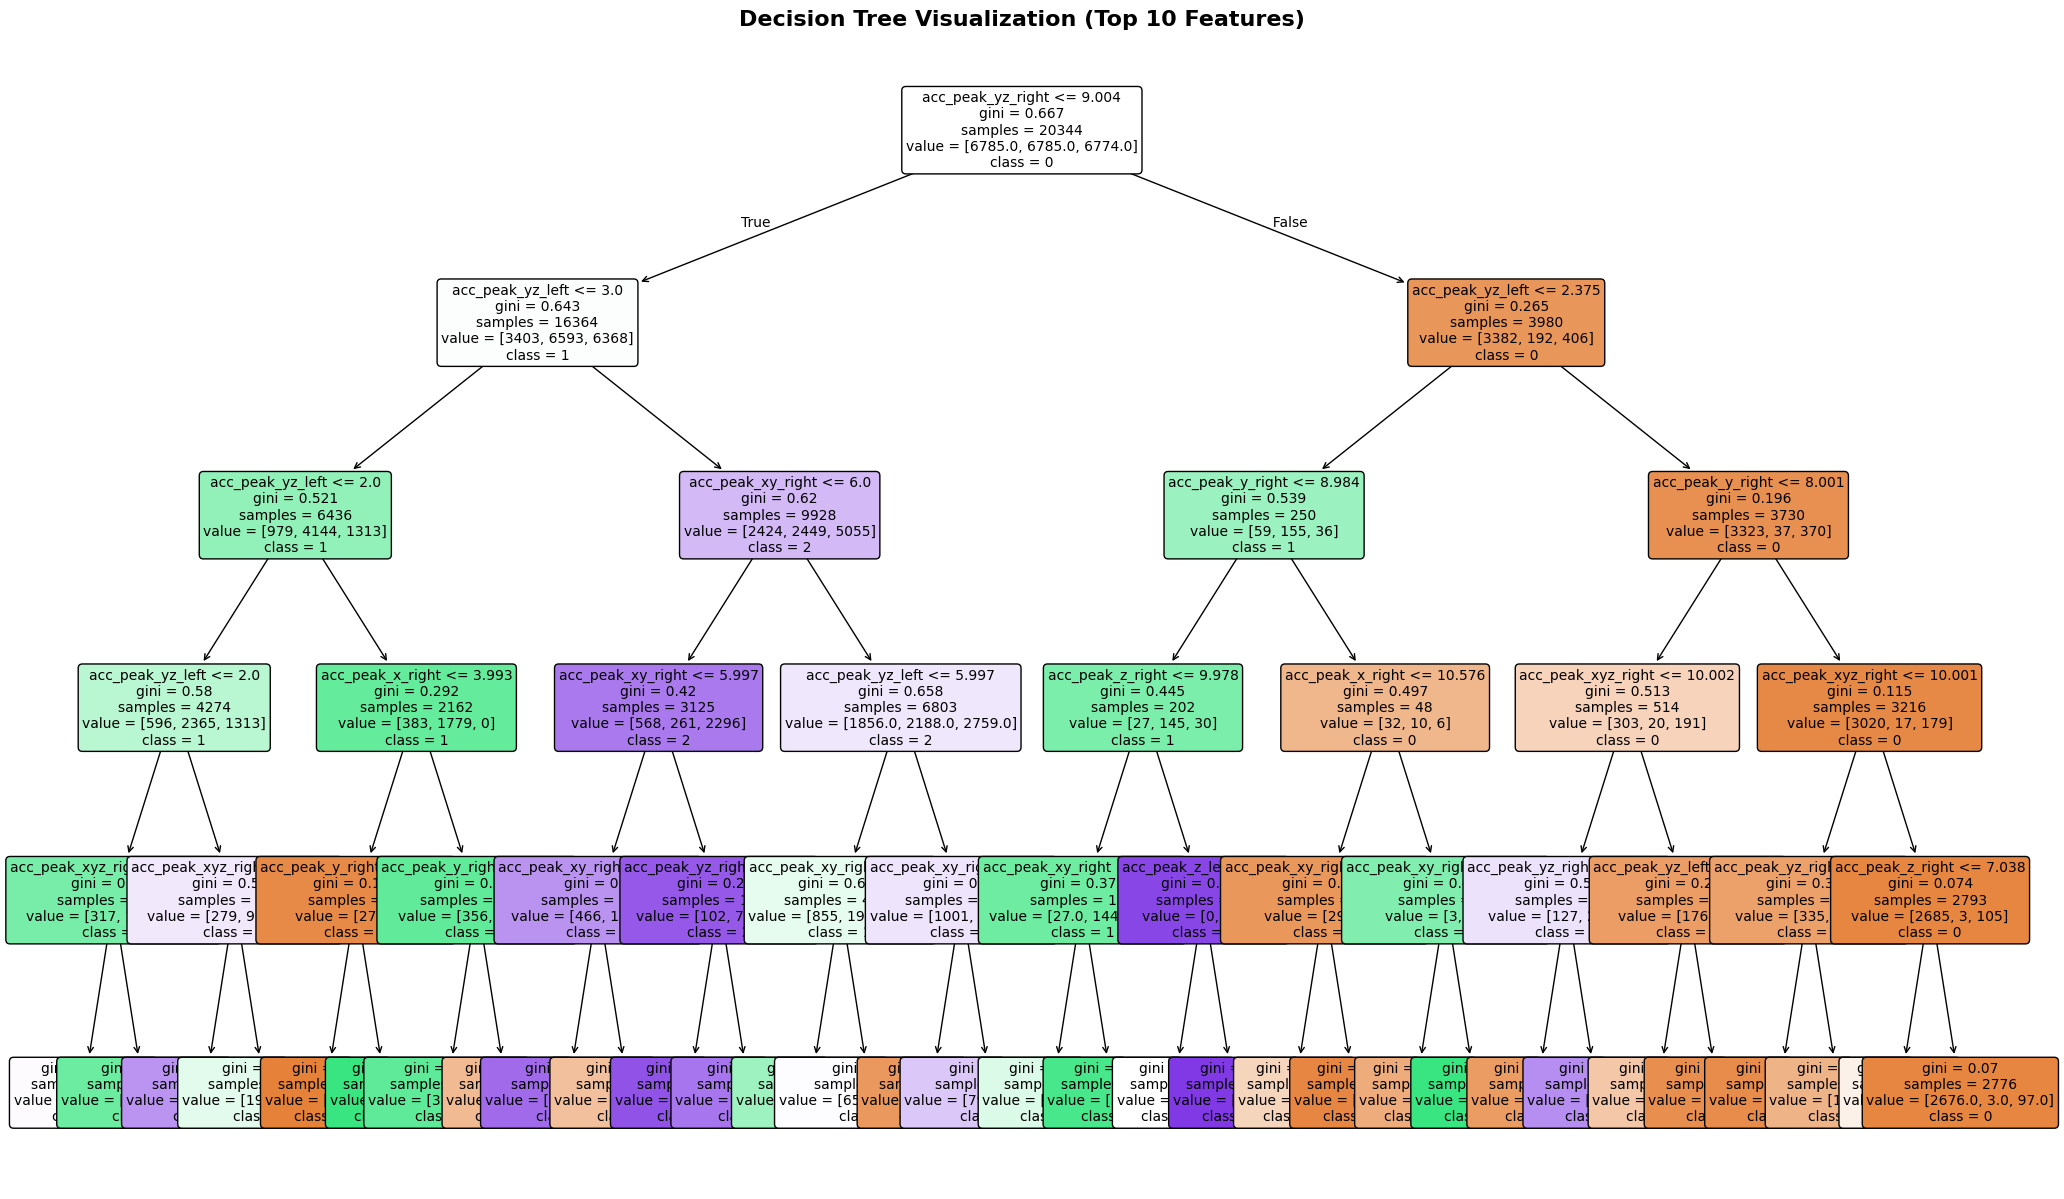

In [199]:
# Plot the tree
print("\nGenerating tree visualization...")
plt.figure(figsize=(25, 15))
plot_tree(dt_loaded,
          feature_names=top_10_features,
          class_names=[str(i) for i in sorted(np.unique(y_train_balanced))],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization (Top 10 Features)', fontsize=16, fontweight='bold')
plt.savefig('decision_tree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [200]:
# Export tree as text
tree_text = export_text(dt_loaded, feature_names=top_10_features)
print("\nDecision Tree Text Representation:")
print(tree_text)

with open('decision_tree_rules.txt', 'w') as f:
    f.write("Decision Tree Rules (Top 10 Features)\n\n")
    f.write(tree_text)
print("\nTree rules saved to: decision_tree_rules.txt")


Decision Tree Text Representation:
|--- acc_peak_yz_right <= 9.00
|   |--- acc_peak_yz_left <= 3.00
|   |   |--- acc_peak_yz_left <= 2.00
|   |   |   |--- acc_peak_yz_left <= 2.00
|   |   |   |   |--- acc_peak_xyz_right <= 6.01
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- acc_peak_xyz_right >  6.01
|   |   |   |   |   |--- class: 1
|   |   |   |--- acc_peak_yz_left >  2.00
|   |   |   |   |--- acc_peak_xyz_right <= 6.01
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- acc_peak_xyz_right >  6.01
|   |   |   |   |   |--- class: 1
|   |   |--- acc_peak_yz_left >  2.00
|   |   |   |--- acc_peak_x_right <= 3.99
|   |   |   |   |--- acc_peak_y_right <= 4.92
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- acc_peak_y_right >  4.92
|   |   |   |   |   |--- class: 1
|   |   |   |--- acc_peak_x_right >  3.99
|   |   |   |   |--- acc_peak_y_right <= 9.02
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- acc_peak_y_right >  9.02
|   |   |   |   |   |--- class: 0
|   |--